# Introducción

## Librería

In [1]:
import os  # Interacción con el sistema operativo: manejar rutas, archivos y variables de entorno
from pathlib import Path  # Manejo seguro y portátil de rutas de archivos y carpetas
import warnings  # Control de advertencias en tiempo de ejecución
import math  # Funciones matemáticas estándar (raíz cuadrada, trigonometría, logaritmos, etc.)
import random  # Generación de números aleatorios y control de semilla
import tensorflow as tf

import keras  # Framework de alto nivel para construir y entrenar redes neuronales
from keras import layers  # Tipos de capas en redes neuronales (Dense, Conv2D, LSTM...)

import numpy as np  # Operaciones numéricas eficientes con arrays y matrices
import pandas as pd  # Manipulación y análisis de datos en estructuras DataFrame
import matplotlib.pyplot as plt  # Visualización de datos (gráficos, histogramas, curvas)
from keras.applications import EfficientNetB0 # Importa la versión B0 de EfficientNet, un modelo preentrenado en ImageNet
import tensorflow_datasets as tfds # Importa TensorFlow Datasets, para cargar datasets predefinidos de manera fácil

warnings.filterwarnings("ignore")  # Ignorar todas las advertencias para evitar ruido en la salida
# os.environ["KERAS_BACKEND"] = "jax"  # Configuración opcional: usar JAX como backend de Keras
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Mostrar solo advertencias y errores de TensorFlow (oculta info y logs)

from tensorflow import keras  # Usar Keras integrado en TensorFlow 2.x
from tensorflow.keras import layers  # Acceso a capas de Keras dentro de TensorFlow
from tensorflow import data as tf_data  # Submódulo para manejo eficiente de datasets y pipelines
import zipfile  # Módulo de Python para trabajar con archivos ZIP


seed = 13  # Valor fijo para reproducibilidad de resultados
np.random.seed(seed)  # Semilla para operaciones aleatorias de NumPy
random.seed(seed)  # Semilla para el módulo random de Python
keras.utils.set_random_seed(seed)  # Semilla para reproducibilidad en TensorFlow/Keras

from IPython.core.magic import register_cell_magic  # Permite crear "magias" personalizadas de celda en Jupyter/Colab

In [2]:
# Configura el tamaño de fuente general por defecto en los gráficos
plt.rc('font', size=14)

# Configura el tamaño de las etiquetas de los ejes (x, y) y el tamaño del título del gráfico
plt.rc('axes', labelsize=14, titlesize=14)

# Configura el tamaño de la fuente de la leyenda del gráfico
plt.rc('legend', fontsize=14)

# Configura el tamaño de las etiquetas en el eje x (números o categorías)
plt.rc('xtick', labelsize=10)

# Configura el tamaño de las etiquetas en el eje y (números o categorías)
plt.rc('ytick', labelsize=10)

## Funciones

In [3]:
# Crea la ruta donde se guardarán las imágenes
IMAGES_PATH = Path() / "images" / "CNN-IPN_mod6"

# Crea la carpeta si no existe
# parents=True permite crear también carpetas intermedias
# exist_ok=True evita error si la carpeta ya existe
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

# Función para guardar figuras generadas con matplotlib
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):

    # Construye la ruta completa del archivo usando el nombre de la figura
    # Ejemplo: images/ann/grafica1.png
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"

    # Ajusta automáticamente los espacios del gráfico para evitar que se encimen etiquetas o títulos
    if tight_layout:
        plt.tight_layout()

    # Guarda la figura en la ruta especificada
    # format = tipo de archivo (png, jpg, pdf, etc.)
    # dpi = resolución de la imagen (300 es calidad alta para artículos o reportes)
    plt.savefig(path, format=fig_extension, dpi=resolution)


def mostrar_imagen_grises(imagen, cmap="binary"):
    """
    Muestra una imagen en escala de grises.

    Parámetros:
    imagen : array-like
        Imagen a mostrar.
    cmap : str, opcional
        Mapa de color (por defecto 'binary').

    Nota:
    - Valores pequeños → blanco
    - Valores grandes → negro
    """
    plt.imshow(imagen, cmap=cmap)
    plt.axis('off')  # Oculta los ejes
    plt.show()       # Muestra la imagen

def mostrar_guardar_imagenes(n_rows, n_cols, x_train, y_train, nombre_guardar, titulo):
    """
    Genera una figura con una cuadrícula de imágenes, coloca títulos a cada imagen,
    agrega un título general y guarda la figura en un archivo.

    Parámetros:
        n_rows (int): Número de filas en la cuadrícula.
        n_cols (int): Número de columnas en la cuadrícula.
        x_train (array-like): Conjunto de imágenes a mostrar.
        y_train (array-like): Etiquetas de las imágenes.
        nombre_guardar (str): Nombre del archivo para guardar la figura.
        titulo (str): Título general de la figura.
    """

    plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))

    # Título general
    plt.suptitle(titulo, fontsize=16)

    for row in range(n_rows):
        for col in range(n_cols):
            index = n_cols * row + col
            if index >= len(x_train):
                break  # Evita errores si x_train tiene menos imágenes

            plt.subplot(n_rows, n_cols, index + 1)
            plt.imshow(x_train[index], cmap="binary", interpolation="nearest")
            plt.axis('off')
            plt.title(y_train[index], fontsize=8)

    plt.subplots_adjust(wspace=0.2, hspace=0.5, top=0.88)  # Ajusta el espacio para el título
    save_fig(nombre_guardar)  # Guarda la figura
    plt.show()  # Muestra la figura



def plot_learning_curves_clasificacion(history, nombre_imagen):
    # Convertir a DataFrame
    df = pd.DataFrame(history.history)

    # Crear figura
    fig, ax = plt.subplots(figsize=(8, 5))

    # Graficar pérdida
    if 'loss' in df and 'val_loss' in df:
        ax.plot(df.index + 1, df['loss'], "r--", label="Train Loss")
        ax.plot(df.index + 1, df['val_loss'], "b--.", label="Val Loss")

    # Graficar accuracy (clasificación)
    if 'accuracy' in df and 'val_accuracy' in df:
        ax.plot(df.index + 1, df['accuracy'], "r-", label="Train Accuracy")
        ax.plot(df.index + 1, df['val_accuracy'], "b-*", label="Val Accuracy")

    # Configuración de ejes
    ax.set_xlim(1, len(df))
    ax.set_ylim(0, 1)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Metric Value")
    ax.grid(True)

    # Leyenda fuera del gráfico
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    # Guardar y mostrar
    plt.tight_layout()
    plt.savefig(nombre_imagen)
    plt.show()



def mostrar_imagenes_RBG(dataset, class_names, nombre_guardar, titulo='', num_imagenes=10, columnas=5):

    """
    Muestra imágenes de un dataset de TensorFlow en una cuadrícula ajustable y guarda la figura.
    """

    filas = math.ceil(num_imagenes / columnas)  # Calcula número de filas necesarias
    plt.figure(figsize=(3*columnas, 3*filas))  # Crea la figura con tamaño proporcional

    titulo = f"Visualización de {num_imagenes} imágenes de ejemplo {titulo}"  # Construye título principal
    plt.suptitle(titulo, fontsize=16)  # Coloca título en la figura

    cont = 0  # Contador de subplots

    for images, labels in dataset.take(1):  # Itera sobre la primera tanda de imágenes
        for i in range(min(num_imagenes, len(images))):  # Limita al número de imágenes deseadas
            ax = plt.subplot(filas, columnas, cont + 1)  # Crea subplot en cuadrícula
            plt.imshow(np.array(images[i]).astype("uint8"))  # Muestra la imagen en uint8
            label_idx = int(labels[i])  # Obtiene índice de clase
            plt.title(f"{class_names[label_idx]} - ({label_idx})")  # Título de cada imagen
            plt.axis("off")  # Quita ejes
            cont += 1  # Incrementa contador de subplots

    plt.subplots_adjust(wspace=0.2, hspace=0.5, top=0.88)  # Ajusta espacios entre subplots y título
    save_fig(f"{nombre_guardar}.png")  # Guarda la figura en archivo PNG
    plt.show()  # Muestra la figura en pantalla


def mostrar_imagenes_RBG2(dataset, class_names, nombre_guardar=None, titulo='', num_imagenes=10, columnas=5):
    """
    Muestra imágenes de un dataset de TensorFlow en un grid ajustable y opcionalmente guarda la figura.
    Funciona tanto para datasets en batch como para datasets sin batch.
    """

    filas = math.ceil(num_imagenes / columnas)  # Calcula el número de filas necesarias para el grid
    plt.figure(figsize=(3*columnas, 3*filas))  # Ajusta el tamaño de la figura según columnas y filas

    if titulo:
        titulo = f"Visualización de {num_imagenes} imágenes de ejemplo {titulo}"  # Construye título principal
        plt.suptitle(titulo, fontsize=16)  # Coloca título en la figura

    cont = 0  # Contador de imágenes mostradas

    for element in dataset.take(num_imagenes):  # Itera sobre el dataset, limitado a num_imagenes
        if isinstance(element, tuple) and len(element) == 2:  # Verifica que el elemento sea (images, labels)
            images, labels = element  # Separa imágenes y etiquetas

            if len(images.shape) > 3:  # Caso batch: varias imágenes juntas (batch, H, W, C)
                for i in range(len(images)):  # Itera sobre cada imagen en el batch
                    if cont >= num_imagenes:  # Rompe si se alcanza el límite
                        break
                    plt.subplot(filas, columnas, cont + 1)  # Crea un subplot en la cuadrícula
                    plt.imshow(np.array(images[i]).astype("uint8"))  # Muestra la imagen convertida a uint8
                    plt.title(f"{class_names[int(labels[i])]} - ({int(labels[i])})")  # Título con nombre y índice de clase
                    plt.axis("off")  # Quita los ejes
                    cont += 1  # Incrementa contador
            else:  # Caso imagen individual: (H, W, C)
                plt.subplot(filas, columnas, cont + 1)  # Crea subplot
                plt.imshow(np.array(images).astype("uint8"))  # Muestra imagen
                plt.title(f"{class_names[int(labels)]} - ({int(labels)})")  # Título con nombre e índice de clase
                plt.axis("off")  # Quita los ejes
                cont += 1  # Incrementa contador

    plt.subplots_adjust(wspace=0.3, hspace=0.5, top=0.88)  # Ajusta espacio entre subplots y margen superior

    if nombre_guardar:  # Si se proporciona un nombre de archivo
        plt.savefig(f"{nombre_guardar}.png")  # Guarda la figura como PNG

    plt.show()  # Muestra la figura en pantalla

def mostrar_imagenes_RGB3(dataset, class_names, nombre_guardar=None, titulo='', num_imagenes=10, columnas=5):
    import math
    filas = math.ceil(num_imagenes / columnas)
    plt.figure(figsize=(3*columnas, 3*filas))

    if titulo:
        plt.suptitle(f"Visualización: {titulo}", fontsize=16)

    cont = 0
    for element in dataset.take(num_imagenes):
        images, labels = element if (isinstance(element, tuple) and len(element) == 2) else (element, None)

        # Normalizar a lista para iterar igual batch o single
        if len(images.shape) > 3:
            curr_imgs, curr_lbls = images, labels
        else:
            curr_imgs, curr_lbls = [images], [labels]

        for i in range(len(curr_imgs)):
            if cont >= num_imagenes: break

            plt.subplot(filas, columnas, cont + 1)
            img = curr_imgs[i].numpy() if hasattr(curr_imgs[i], 'numpy') else curr_imgs[i]

            # Mostrar según tipo de dato (float 0-1 o int 0-255)
            if img.dtype.kind == 'f':
                plt.imshow(np.clip(img, 0, 1))
            else:
                plt.imshow(img.astype("uint8"))

            if curr_lbls is not None:
                idx = int(curr_lbls[i])
                plt.title(f"{class_names[idx]}\n({idx})", fontsize=10)

            plt.axis("off")
            cont += 1

    plt.subplots_adjust(wspace=0.3, hspace=0.6, top=0.85)

    if nombre_guardar:
        # Usamos plt.savefig directamente para evitar el error de save_fig()
        save_fig(f"{nombre_guardar}.png")
        print(f"Imagen guardada como: {nombre_guardar}.png")

    plt.show()

def resumen_dataset_imagekeras(dataset, nombre):
    # Creamos un arreglo de ceros con tamaño igual al número de clases
    # Aquí iremos acumulando cuántas imágenes hay por clase
    counts = np.zeros(len(dataset.class_names), dtype=int)

    # Recorremos el dataset batch por batch
    # _ representa las imágenes (no las usamos aquí)
    # labels son las etiquetas de cada imagen en el batch
    for _, labels in dataset:
        # Recorremos cada etiqueta dentro del batch
        for label in labels:
            # label.numpy() convierte el tensor a número (ej: 0, 1, 2...)
            # Sumamos 1 al contador de esa clase
            counts[label.numpy()] += 1

    # Calculamos el total de imágenes sumando todos los conteos
    total = counts.sum()

    # Imprimimos el nombre del dataset (Train o Validation)
    print(f"\n        {nombre}        ")
    print(f"Total imágenes: {total}\n")

    # Encabezados de la tabla
    print(f"{'Clase':<15}{'Cantidad':<10}{'Proporción'}")
    print("-"*35)

    # Recorremos cada clase para mostrar sus datos
    for i, class_name in enumerate(dataset.class_names):
        # Calculamos la proporción de esa clase respecto al total
        propor = counts[i] / total

        # Mostramos: nombre de la clase, cantidad y proporción
        print(f"{class_name:<15}{counts[i]:<10}{propor:.3f}")


def resumen_dataset_imagekeras2(dataset, class_names, nombre):
    """
    Resume el dataset mostrando cantidad de imágenes por clase y proporción.
    Funciona tanto para datasets con batch como sin batch.

    Args:
        dataset: tf.data.Dataset que devuelve (imagen, label)
        class_names: lista de nombres de clases
        nombre: nombre descriptivo del dataset (ej. "Train" o "Validation")
    """

    # Inicializamos contador por clase
    counts = np.zeros(len(class_names), dtype=int)

    for element in dataset:  # Itera sobre todos los elementos
        if isinstance(element, tuple) and len(element) == 2:
            images, labels = element

            # Caso batch (varias etiquetas)
            if len(labels.shape) > 0:
                for label in labels:
                    counts[int(label.numpy())] += 1
            else:  # Caso etiqueta individual
                counts[int(labels.numpy())] += 1

    total = counts.sum()  # Total de imágenes

    # Mostramos resumen
    print(f"\n        {nombre}        ")
    print(f"Total imágenes: {total}\n")

    print(f"{'Clase':<15}{'Cantidad':<10}{'Proporción'}")
    print("-"*35)

    for i, class_name in enumerate(class_names):
        propor = counts[i] / total
        print(f"{class_name:<15}{counts[i]:<10}{propor:.3f}")

# Función que aplica el aumento de datos a un batch de imágenes
def data_augmentation(images):
    # Recorre cada capa de aumento definida
    for layer in data_augmentation_layers:
        # Aplica la transformación actual a las imágenes
        images = layer(images)

    # Devuelve las imágenes transformadas
    return images






def mostrar_imagenes_aumentadas_imageskeras(dataset, class_names, nombre_guardar, titulo='',
                                num_imagenes=3, num_aumentos=4, columnas=4):
    """
    Muestra imágenes aumentadas (data augmentation) de un dataset en una cuadrícula
    y guarda la figura.

    - num_imagenes: número de imágenes distintas a usar
    - num_aumentos: número de transformaciones por imagen
    """

    filas = num_imagenes  # una fila por imagen base
    plt.figure(figsize=(3*columnas, 3*filas))  # tamaño proporcional

    titulo = f"Imágenes aumentadas ({num_imagenes}x{num_aumentos}) {titulo}"
    plt.suptitle(titulo, fontsize=16)

    cont = 0  # contador de subplots

    for images, labels in dataset.take(1):  # tomamos un batch

        for j in range(min(num_imagenes, len(images))):  # imágenes distintas

            img = images[j:j+1]  # batch de tamaño 1
            label = int(labels[j])  # etiqueta

            for i in range(num_aumentos):  # aumentos por imagen

                augmented_img = data_augmentation(img)  # aplicar augmentation

                ax = plt.subplot(filas, columnas, cont + 1)

                plt.imshow(np.array(augmented_img[0]).astype("uint8"))

                # título con clase y número de aumento
                plt.title(f"{class_names[label]} ({label}) - aug {i+1}")

                plt.axis("off")
                cont += 1

    plt.subplots_adjust(wspace=0.2, hspace=0.5, top=0.88)
    save_fig(f"{nombre_guardar}.png")
    plt.show()



def mostrar_imagenes_aumentadas_imageskeras2(dataset, class_names, nombre_guardar, titulo='',
                                             num_imagenes=1, num_aumentos=9, columnas=3):
    """
    Muestra imágenes aumentadas de un dataset de TensorFlow/Keras y guarda la figura.

    Parámetros:
    - dataset: conjunto de datos de TensorFlow (images, labels)
    - class_names: lista de nombres de clases
    - nombre_guardar: ruta/nombre del archivo para guardar la figura
    - titulo: título opcional de la figura
    - num_imagenes: número de imágenes originales a mostrar
    - num_aumentos: número de aumentos por imagen
    - columnas: número de columnas en la figura
    """

    total_imgs = num_imagenes * num_aumentos  # total de imágenes a mostrar
    filas = math.ceil(total_imgs / columnas)  # filas necesarias

    plt.figure(figsize=(4 * columnas, 3.5 * filas))  # tamaño de la figura
    plt.suptitle(f"Imágenes aumentadas ({num_imagenes}x{num_aumentos}) {titulo}", fontsize=16)

    cont = 0  # contador de subplots
    imagenes_mostradas = 0  # contador de imágenes originales procesadas

    # iterar sobre el dataset hasta obtener num_imagenes
    for images, labels in dataset:
        # asegurar batch
        if len(images.shape) == 3:
            images = np.expand_dims(images, axis=0)
            labels = np.array([labels])

        for j in range(len(images)):
            if imagenes_mostradas >= num_imagenes:
                break  # ya alcanzamos el número de imágenes deseadas

            image = images[j]
            label = int(labels[j])
            image_np = image.numpy() if hasattr(image, "numpy") else image

            # generar num_aumentos por cada imagen
            for i in range(num_aumentos):
                ax = plt.subplot(filas, columnas, cont + 1)

                aug_img = data_augmentation(np.expand_dims(image_np, axis=0))
                aug_img = np.array(aug_img)

                plt.imshow(aug_img[0].astype("uint8"))
                plt.title(f"{class_names[label]} ({label}) - aug {i+1}", pad=12, fontsize=9)
                plt.axis("off")
                cont += 1

            imagenes_mostradas += 1

        if imagenes_mostradas >= num_imagenes:
            break

    plt.subplots_adjust(wspace=0.3, hspace=0.9, top=0.88)
    save_fig(f"{nombre_guardar}.png")
    plt.show()


def mostrar_imagenes_aumentadas_imageskeras3(dataset, class_names, nombre_guardar, titulo='',
                                           num_imagenes=1, num_aumentos=9, columnas=3):
    """
    Muestra imágenes aumentadas recorriendo la LISTA de capas de data_augmentation.
    Maneja automáticamente imágenes normalizadas (0-1).
    """

    total_imgs = num_imagenes * num_aumentos
    filas = math.ceil(total_imgs / columnas)

    plt.figure(figsize=(4 * columnas, 3.5 * filas))
    plt.suptitle(f"Imágenes aumentadas ({num_imagenes}x{num_aumentos}) {titulo}", fontsize=16)

    cont = 0
    imagenes_mostradas = 0

    for images, labels in dataset:
        # Aseguramos que tratamos los datos como tensores para las capas de Keras
        if len(images.shape) == 3:
            images = tf.expand_dims(images, axis=0)
            labels = np.array([labels])

        for j in range(len(images)):
            if imagenes_mostradas >= num_imagenes:
                break

            # Extraemos la imagen original del batch
            original_image = images[j]
            label = int(labels[j])

            # Generar los aumentos solicitados para esta imagen específica
            for i in range(num_aumentos):
                plt.subplot(filas, columnas, cont + 1)

                # --- PROCESO DE AUMENTO CAPA POR CAPA ---
                # Empezamos con la imagen original (añadiendo dimensión de batch)
                aug_img = tf.expand_dims(original_image, axis=0)

                # Iteramos sobre la LISTA de capas (data_augmentation_layers)
                for layer in data_augmentation_layers:
                    aug_img = layer(aug_img, training=True)

                # Quitamos la dimensión de batch [1, H, W, C] -> [H, W, C]
                aug_img = tf.squeeze(aug_img, axis=0).numpy()

                # --- VISUALIZACIÓN INTELIGENTE ---
                # Si los valores son float (0.0 a 1.0), usamos clip para evitar errores
                if aug_img.dtype.kind == 'f':
                    plt.imshow(np.clip(aug_img, 0, 1))
                else:
                    plt.imshow(aug_img.astype("uint8"))

                plt.title(f"{class_names[label]}\n(aug {i+1})", fontsize=9)
                plt.axis("off")
                cont += 1

            imagenes_mostradas += 1

        if imagenes_mostradas >= num_imagenes:
            break

    plt.subplots_adjust(wspace=0.3, hspace=0.6, top=0.9)

    # Guardado seguro usando matplotlib directamente
    if nombre_guardar:
        plt.savefig(f"{nombre_guardar}.png", bbox_inches='tight')
        print(f"Figura guardada exitosamente como: {nombre_guardar}.png")

    plt.show()

# ================================
# One-hot / categorical encoding
# ================================

# Función de preprocesamiento para datos de entrenamiento
def input_preprocess_train(image, label, num_classes):
    image = data_augmentation(image)     # Aplica aumentos de datos a la imagen (rotaciones, flips, cambios de brillo, etc.)
    label = tf.one_hot(label, num_classes)     # Convierte la etiqueta en codificación one-hot según num_classes
    return image, label     # Retorna la imagen y etiqueta preprocesadas


# Función de preprocesamiento para datos de prueba (sin augmentación)
def input_preprocess_test(image, label, num_classes):
    # Solo codifica la etiqueta a one-hot
    label = tf.one_hot(label, num_classes)
    return image, label

# VGG16

In [4]:
IMG_SIZE = 224 # Define el tamaño de la imagen de entrada. EfficientNetB0 espera imágenes de 224x224 píxeles
BATCH_SIZE = 64 # Define el tamaño del batch, es decir, cuántas imágenes se procesan a la vez durante el entrenamiento

In [5]:
dataset_name = "stanford_dogs"
# Cargamos el dataset "Stanford Dogs" usando TensorFlow Datasets
(ds_train, ds_test), ds_info = tfds.load(
    "stanford_dogs",         # Nombre del dataset a cargar
    split=["train", "test"], # Separar en conjunto de entrenamiento y prueba
    with_info=True,          # También devuelve información del dataset (ds_info)
    as_supervised=True,      # Devuelve los datos como pares (imagen, etiqueta)
    data_dir="./tfds_data"   # Carpeta donde se descargará o leerá el dataset
)

Obtengo el tamaño de las primeras $10$ imágenes

In [6]:
print("Dimensiones y rangos de valores (Máx, Mín) de las primeras 10 imágenes:")
for i, (image, label) in enumerate(ds_train.take(10)):
    # Calculamos los valores máximo y mínimo del tensor
    max_val = tf.reduce_max(image).numpy()
    min_val = tf.reduce_min(image).numpy()

    print(f"Imagen {i+1}: {image.shape} | Máximo: {max_val} | Mínimo: {min_val}")

Dimensiones y rangos de valores (Máx, Mín) de las primeras 10 imágenes:
Imagen 1: (500, 333, 3) | Máximo: 255 | Mínimo: 0
Imagen 2: (367, 400, 3) | Máximo: 255 | Mínimo: 0
Imagen 3: (500, 375, 3) | Máximo: 255 | Mínimo: 0
Imagen 4: (321, 450, 3) | Máximo: 255 | Mínimo: 0
Imagen 5: (333, 500, 3) | Máximo: 255 | Mínimo: 0
Imagen 6: (375, 500, 3) | Máximo: 255 | Mínimo: 0
Imagen 7: (500, 470, 3) | Máximo: 255 | Mínimo: 0
Imagen 8: (207, 200, 3) | Máximo: 255 | Mínimo: 0
Imagen 9: (375, 500, 3) | Máximo: 255 | Mínimo: 0
Imagen 10: (500, 333, 3) | Máximo: 255 | Mínimo: 0


In [7]:
# Opción 1: Revisar la información del dataset
print(f"Tipo de etiqueta en ds_info: {ds_info.features['label']}")

# Opción 2: Ver un ejemplo real
for _, label in ds_train.take(1):
    print(f"Valor de la etiqueta: {label.numpy()}")
    print(f"Forma del tensor de la etiqueta: {label.shape}")

Tipo de etiqueta en ds_info: ClassLabel(shape=(), dtype=int64, num_classes=120)
Valor de la etiqueta: 36
Forma del tensor de la etiqueta: ()


In [8]:
size = (IMG_SIZE, IMG_SIZE)
size

(224, 224)

In [9]:
def get_preprocess_fn(target_size=(224, 224)):
    """Crea una función de preprocesamiento con un tamaño específico."""
    def preprocess(image, label):
        # 1. Redimensionar al tamaño deseado
        image = tf.image.resize(image, target_size)

        # 2. Normalizar a [0, 1]
        image = tf.cast(image, tf.float32) / 255.0

        return image, label
    return preprocess

Imágenes redimensionando la imagen y normalizando

In [10]:
ds_train = ds_train.map(get_preprocess_fn(target_size=size))

In [11]:
ds_test = ds_test.map(get_preprocess_fn(target_size=size))

In [12]:
print("Dimensiones y rangos de valores (Máx, Mín) de las primeras 10 imágenes:")
for i, (image, label) in enumerate(ds_train.take(10)):
    # Calculamos los valores máximo y mínimo del tensor
    max_val = tf.reduce_max(image).numpy()
    min_val = tf.reduce_min(image).numpy()

    print(f"Imagen {i+1}: {image.shape} | Máximo: {max_val} | Mínimo: {min_val}")

Dimensiones y rangos de valores (Máx, Mín) de las primeras 10 imágenes:
Imagen 1: (224, 224, 3) | Máximo: 1.0 | Mínimo: 0.0
Imagen 2: (224, 224, 3) | Máximo: 1.0 | Mínimo: 0.02153545804321766
Imagen 3: (224, 224, 3) | Máximo: 1.0 | Mínimo: 0.09094248712062836
Imagen 4: (224, 224, 3) | Máximo: 1.0 | Mínimo: 0.0008490896434523165
Imagen 5: (224, 224, 3) | Máximo: 1.0 | Mínimo: 0.0
Imagen 6: (224, 224, 3) | Máximo: 0.9958951473236084 | Mínimo: 0.002072324976325035
Imagen 7: (224, 224, 3) | Máximo: 1.0 | Mínimo: 0.001542646554298699
Imagen 8: (224, 224, 3) | Máximo: 1.0 | Mínimo: 0.02072601392865181
Imagen 9: (224, 224, 3) | Máximo: 1.0 | Mínimo: 0.0
Imagen 10: (224, 224, 3) | Máximo: 1.0 | Mínimo: 0.0


In [13]:
class_names = ds_info.features['label'].names
# Aplicamos split("-") para quedarnos solo con la parte después del guion
class_names = [name.split("-")[1] for name in class_names]
class_names[:5]


['chihuahua', 'japanese_spaniel', 'maltese_dog', 'pekinese', 'shih']

## Visualización

In [14]:
# Mostramos la descripción del dataset Stanford Dogs
dataset_description = ds_info.description
print(dataset_description)

The Stanford Dogs dataset contains images of 120 breeds of dogs from around the
world. This dataset has been built using images and annotation from ImageNet for
the task of fine-grained image categorization. There are 20,580 images, out of
which 12,000 are used for training and 8580 for testing. Class labels and
bounding box annotations are provided for all the 12,000 images.


In [15]:
class_names = ds_info.features['label'].names
print(f"""
Clases (las primeras 5): {class_names[:5]}
Número de clases: {len(class_names)}""")
class_names = [name.split("-")[1] for name in class_names] # Aplicamos split("-") para quedarnos solo con la parte después del guion
print(f"""
Clases (las primeras 5) sin split: {class_names[:5]}
 """)


Clases (las primeras 5): ['n02085620-chihuahua', 'n02085782-japanese_spaniel', 'n02085936-maltese_dog', 'n02086079-pekinese', 'n02086240-shih-tzu']
Número de clases: 120

Clases (las primeras 5) sin split: ['chihuahua', 'japanese_spaniel', 'maltese_dog', 'pekinese', 'shih']
 


In [16]:
train_size = ds_info.splits['train'].num_examples
test_size = ds_info.splits['test'].num_examples

print(f"Número de imágenes de entrenamiento: {train_size}")
print(f"Número de imágenes de prueba: {test_size}")

Número de imágenes de entrenamiento: 12000
Número de imágenes de prueba: 8580


In [17]:
resumen_dataset_imagekeras2(ds_train,class_names, "Conjunto de entrenamiento")
resumen_dataset_imagekeras2(ds_test,class_names, "Conjunto de prueba")


        Conjunto de entrenamiento        
Total imágenes: 12000

Clase          Cantidad  Proporción
-----------------------------------
chihuahua      100       0.008
japanese_spaniel100       0.008
maltese_dog    100       0.008
pekinese       100       0.008
shih           100       0.008
blenheim_spaniel100       0.008
papillon       100       0.008
toy_terrier    100       0.008
rhodesian_ridgeback100       0.008
afghan_hound   100       0.008
basset         100       0.008
beagle         100       0.008
bloodhound     100       0.008
bluetick       100       0.008
black          100       0.008
walker_hound   100       0.008
english_foxhound100       0.008
redbone        100       0.008
borzoi         100       0.008
irish_wolfhound100       0.008
italian_greyhound100       0.008
whippet        100       0.008
ibizan_hound   100       0.008
norwegian_elkhound100       0.008
otterhound     100       0.008
saluki         100       0.008
scottish_deerhound100       0.008
weimaraner

## Data augmentation

In [18]:
# Lista de capas de data augmentation (aumentos artificiales de imágenes)
img_augmentation_layers = [
    # Rota la imagen aleatoriamente dentro de un rango factor=0.15 significa hasta ±15% de 360° (~±54°)
    layers.RandomRotation(factor=0.15),

    # Desplaza la imagen horizontal y verticalmente
    # height_factor=0.1 → hasta 10% en vertical
    # width_factor=0.1 → hasta 10% en horizontal
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),

    # Voltea la imagen aleatoriamente (horizontal y/o vertical dependiendo configuración por defecto)
    layers.RandomFlip(),

    # Ajusta el contraste de la imagen aleatoriamente
    # factor=0.1 → cambia el contraste en un rango moderado
    layers.RandomContrast(factor=0.1),
]


In [19]:
# Definimos una lista de capas de aumento de datos (Data Augmentation)
# Estas capas ayudan a que el modelo no se "memorice" las fotos (evita el overfitting)
data_augmentation_layers = [
    # Voltea la imagen de izquierda a derecha. Útil porque un perro mirando a la
    # izquierda sigue siendo el mismo perro si mira a la derecha.
    layers.RandomFlip("horizontal"),

    # Rota la imagen aleatoriamente un ±15% de 360 grados (aprox. ±54°).
    # Ayuda a reconocer al animal aunque la foto esté algo inclinada.
    layers.RandomRotation(0.15),

    # Hace zoom hacia adentro o hacia afuera un 20%.
    # Simula que el perro está a diferentes distancias de la cámara.
    layers.RandomZoom(0.2),

    # Modifica el contraste de forma aleatoria en un rango del 20%.
    # Útil para fotos con mucha sombra o mucha luz (exposición variable).
    layers.RandomContrast(0.2),

    # Desplaza la imagen horizontal y verticalmente un 10%.
    # Enseña al modelo que el perro no siempre estará perfectamente centrado.
    layers.RandomTranslation(0.1, 0.1)
]

In [20]:
def mostrar_imagenes_aumentadas_imageskeras3(dataset, class_names, nombre_guardar, titulo='',
                                           num_imagenes=1, num_aumentos=9, columnas=3):
    """
    Muestra imágenes aumentadas recorriendo la LISTA de capas de data_augmentation.
    Maneja automáticamente imágenes normalizadas (0-1).
    """

    total_imgs = num_imagenes * num_aumentos
    filas = math.ceil(total_imgs / columnas)

    plt.figure(figsize=(4 * columnas, 3.5 * filas))
    plt.suptitle(f"Imágenes aumentadas ({num_imagenes}x{num_aumentos}) {titulo}", fontsize=16)

    cont = 0
    imagenes_mostradas = 0

    for images, labels in dataset:
        # Aseguramos que tratamos los datos como tensores para las capas de Keras
        if len(images.shape) == 3:
            images = tf.expand_dims(images, axis=0)
            labels = np.array([labels])

        for j in range(len(images)):
            if imagenes_mostradas >= num_imagenes:
                break

            # Extraemos la imagen original del batch
            original_image = images[j]
            label = int(labels[j])

            # Generar los aumentos solicitados para esta imagen específica
            for i in range(num_aumentos):
                plt.subplot(filas, columnas, cont + 1)

                # --- PROCESO DE AUMENTO CAPA POR CAPA ---
                # Empezamos con la imagen original (añadiendo dimensión de batch)
                aug_img = tf.expand_dims(original_image, axis=0)

                # Iteramos sobre la LISTA de capas (data_augmentation_layers)
                for layer in data_augmentation_layers:
                    aug_img = layer(aug_img, training=True)

                # Quitamos la dimensión de batch [1, H, W, C] -> [H, W, C]
                aug_img = tf.squeeze(aug_img, axis=0).numpy()

                # --- VISUALIZACIÓN INTELIGENTE ---
                # Si los valores son float (0.0 a 1.0), usamos clip para evitar errores
                if aug_img.dtype.kind == 'f':
                    plt.imshow(np.clip(aug_img, 0, 1))
                else:
                    plt.imshow(aug_img.astype("uint8"))

                plt.title(f"{class_names[label]}\n(aug {i+1})", fontsize=9)
                plt.axis("off")
                cont += 1

            imagenes_mostradas += 1

        if imagenes_mostradas >= num_imagenes:
            break

    plt.subplots_adjust(wspace=0.3, hspace=0.6, top=0.9)

    # Guardado seguro usando matplotlib directamente
    if nombre_guardar:
        plt.savefig(f"{nombre_guardar}.png", bbox_inches='tight')
        print(f"Figura guardada exitosamente como: {nombre_guardar}.png")

    plt.show()

Figura guardada exitosamente como: aumentacion_v2.png


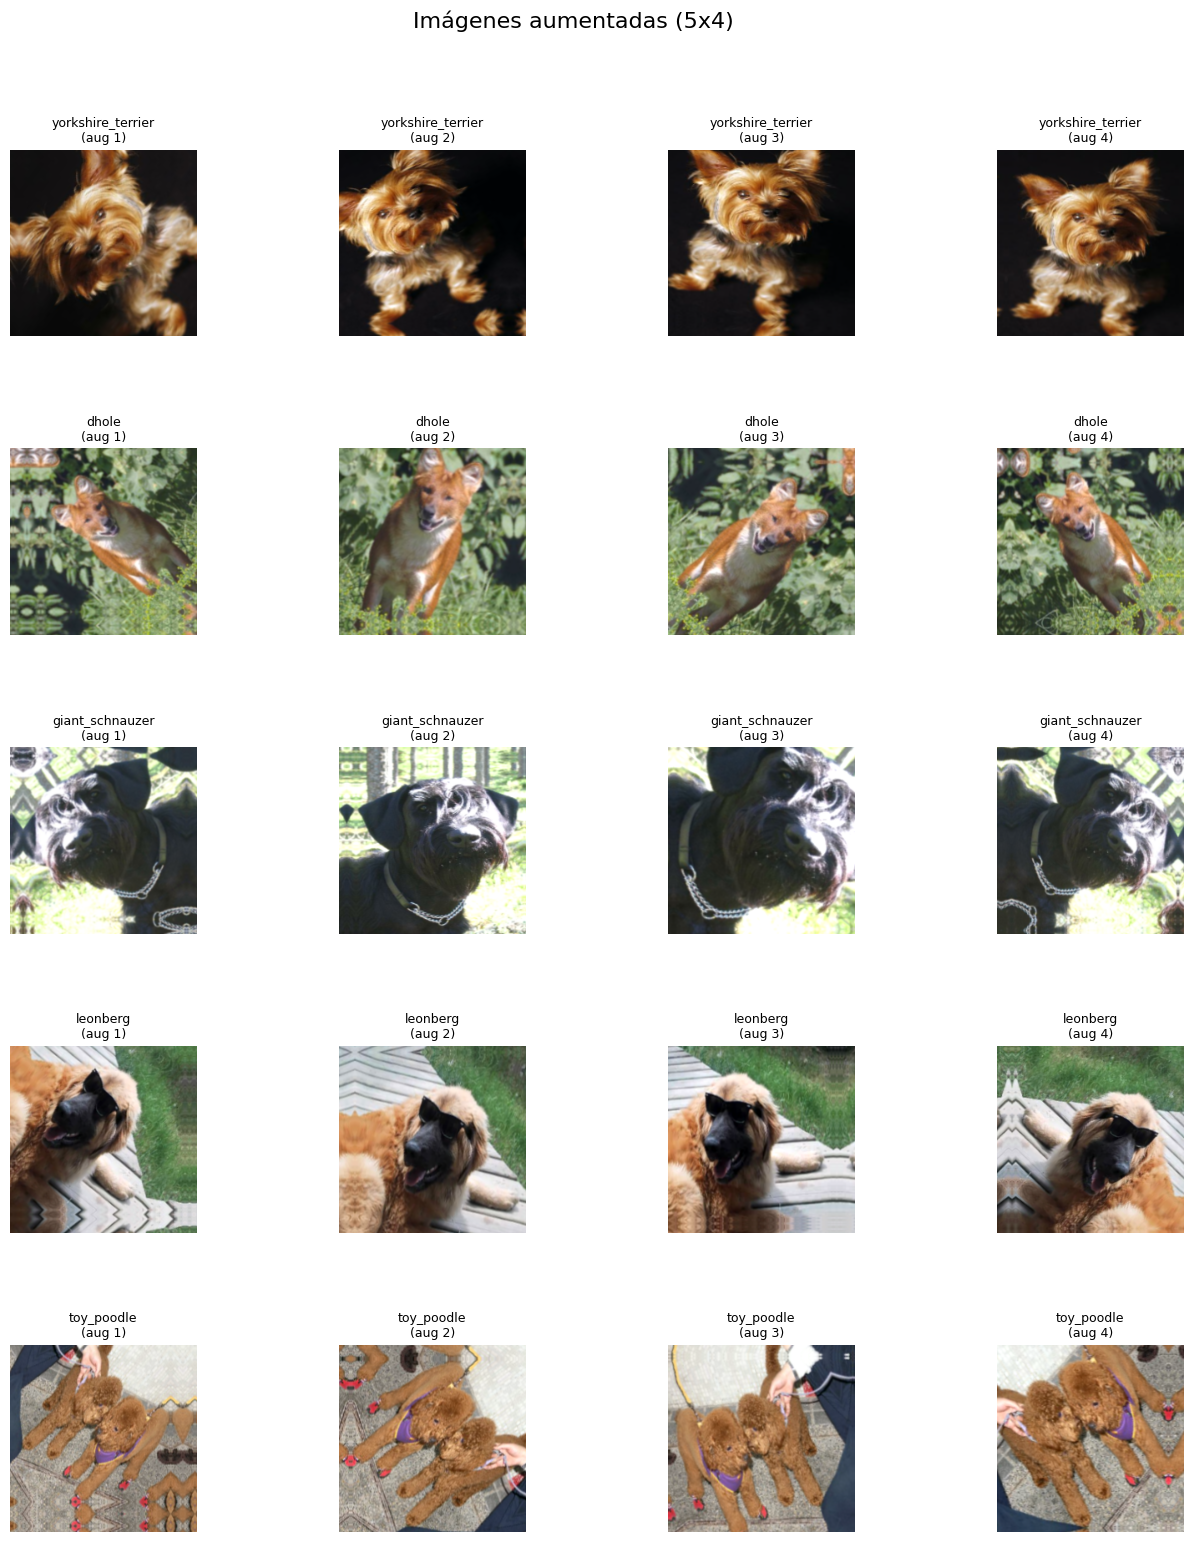

In [21]:
mostrar_imagenes_aumentadas_imageskeras3(
    dataset=ds_train,
    class_names=class_names,
    nombre_guardar="aumentacion_v2",
    num_imagenes=5,
    num_aumentos=4,
    columnas=4
)

In [22]:
num_classes = len(class_names)
num_classes

120

In [23]:
EPOCHS = 5

In [24]:
# ==========================
# Pipeline Corregido
# ==========================

# 1. El Shuffle debe ir PRIMERO (antes de agrupar en lotes)
# El buffer_size debe ser al menos de 1000 para que el mezclado sea efectivo
ds_train = ds_train.shuffle(
    buffer_size=1000,
    reshuffle_each_iteration=True
)

# 2. Tu mapeo de preprocesamiento (asegúrate de que incluya preprocess_input de VGG)
ds_train = ds_train.map(
    lambda x, y: input_preprocess_train(x, y, num_classes),
    num_parallel_calls=tf.data.AUTOTUNE
)

# 3. El agrupamiento en lotes
ds_train = ds_train.batch(
    batch_size=BATCH_SIZE,
    drop_remainder=True
)

# 4. El prefetch para que la CPU no sea el cuello de botella
ds_train = ds_train.prefetch(
    tf.data.AUTOTUNE
)

In [25]:
ds_test = ds_test.map(
      lambda x, y: input_preprocess_test(x, y, num_classes),  # función que recibe (imagen, etiqueta) y devuelve (imagen_preprocesada, etiqueta)
    num_parallel_calls=tf.data.AUTOTUNE  # permite decidir automáticamente cuántos hilos usar para paralelizar el preprocesamiento
)

ds_test = ds_test.batch(
    batch_size=BATCH_SIZE,                     # batch_size=BATCH_SIZE: tamaño de cada lote de datos
    drop_remainder=True                        # descarta el último lote si no tiene exactamente batch_size elementos
)

In [26]:
EPOCHS

5

In [ ]:
# ==========================
# 1. Montar Google Drive
# ==========================
from google.colab import drive
drive.mount('/content/drive')
EPOCHS=40

# ==========================
# 2. Configurar carpeta de checkpoints
# ==========================
import os

checkpoint_dir = '/content/drive/MyDrive/ModelosVGG/'

if not os.path.exists(checkpoint_dir):
    print("No existe la carpeta de modelos. Creando...")
    os.makedirs(checkpoint_dir)
else:
    print("La carpeta de modelos ya existe.")

# Archivo donde se guardará el último modelo
checkpoint_path = os.path.join(checkpoint_dir, 'vgg_latest.keras')

# ==========================
# 3. Revisar si hay modelo previo
# ==========================
import tensorflow as tf
import glob

model_files = glob.glob(os.path.join(checkpoint_dir, '*.keras'))

if model_files:
    latest_model = max(model_files, key=os.path.getctime)
    print("Cargando modelo existente:", latest_model)
    model = tf.keras.models.load_model(latest_model)
else:
    print("No se encontró modelo previo. Creando uno nuevo.")

    # ==========================
    # 4. Crear modelo VGG16
    # ==========================
    from tensorflow.keras.applications import VGG16
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Flatten, Dense, Dropout
    from tensorflow.keras.applications.vgg16 import preprocess_input

    vgg_base = VGG16(
    include_top=False,           # No incluimos las capas densas finales
    weights='imagenet',          # Usamos pesos preentrenados
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Congelamos la base para no destruir el conocimiento de ImageNet
    vgg_base.trainable = False

    # Descongelar últimas 3 capas de VGG16
    #vgg_base.trainable = False
    #for layer in vgg_base.layers[:-4]:
    #  layer.trainable = False

    # 4. Modelo con capas densas más pequeñas para CPU
    model = keras.Sequential([
      # Esta capa convierte tus datos normalizados al formato VGG
      layers.Lambda(preprocess_input, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
      vgg_base,
      # 3. Cabeza personalizada (Reducida para estabilidad)
      layers.GlobalAveragePooling2D(), # Esto ayuda muchísimo a la estabilidad

      layers.Dense(256, activation='relu'),
      layers.BatchNormalization(),
      layers.Dropout(0.4), # Evita que el modelo se memorice los batches

      layers.Dense(num_classes, activation='softmax')

    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

# ==========================
# 5. Configurar callback de checkpoint
# ==========================
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=False,
    save_freq='epoch',
    verbose=1
)

# ==========================
# 6. Entrenamiento
# ==========================

EPOCHS = 10

history = model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=EPOCHS,
    callbacks=[checkpoint_callback]  # Aquí añadimos el guardado automático
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
La carpeta de modelos ya existe.
Cargando modelo existente: /content/drive/MyDrive/ModelosVGG/vgg_latest.keras
Epoch 1/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2346 - loss: 3.1261
Epoch 1: saving model to /content/drive/MyDrive/ModelosVGG/vgg_latest.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ModelosVGG/vgg_latest.keras
187/187 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.2263 - loss: 3.1354 - val_accuracy: 0.2867 - val_loss: 2.8331
Epoch 2/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2293 - loss: 3.1259
Epoch 2: saving model to /content/drive/MyDrive/ModelosVGG/vgg_latest.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ModelosVGG/vgg_latest.keras
187/187 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.2302 - loss: 3.1218 - val_accuracy: 0.2949 - val_loss: 2.8179
Epoch 3/10
187/187 ━━━━━━━━━━━

In [ ]:
# ==========================
# 1. Montar Google Drive
# ==========================
from google.colab import drive
drive.mount('/content/drive')

# ==========================
# 2. Configurar carpeta de checkpoints
# ==========================
import os

checkpoint_dir = '/content/drive/MyDrive/ModelosVGG/'

if not os.path.exists(checkpoint_dir):
    print("No existe la carpeta de modelos. Creando...")
    os.makedirs(checkpoint_dir)
else:
    print("La carpeta de modelos ya existe.")

# Archivo donde se guardará el último modelo
checkpoint_path = os.path.join(checkpoint_dir, 'vgg_latest.h5')

# ==========================
# 3. Revisar si hay modelo previo
# ==========================
import tensorflow as tf
import glob

model_files = glob.glob(os.path.join(checkpoint_dir, '*.h5'))

if model_files:
    latest_model = max(model_files, key=os.path.getctime)
    print("Cargando modelo existente:", latest_model)
    model = tf.keras.models.load_model(latest_model)
else:
    print("No se encontró modelo previo. Creando uno nuevo.")

    # ==========================
    # 4. Crear modelo VGG16
    # ==========================
    from tensorflow.keras.applications import VGG16
    from tensorflow.keras.models import Model
    from tensorflow.keras.layers import Flatten, Dense, Dropout


    vgg_base = VGG16(
    include_top=False,           # No incluimos las capas densas finales
    weights='imagenet',          # Usamos pesos preentrenados
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Descongelar últimas 3 capas de VGG16
    vgg_base.trainable = False
    #for layer in vgg_base.layers[:-4]:
    #  layer.trainable = False

    # 4. Modelo con capas densas más pequeñas para CPU
    model = keras.Sequential([
      vgg_base,
      # GlobalAveragePooling2D es MUCHO mejor que Flatten para CPU.
      # Reduce los parámetros de millones a miles, haciendo el modelo más rápido.
      layers.GlobalAveragePooling2D(),

      # Una capa densa sólida para procesar las 120 clases
      layers.Dense(256, activation='relu'),
      layers.Dropout(0.3), # Un solo dropout moderado es suficiente

      # Capa de salida: 120 neuronas para las 120 razas
      layers.Dense(num_classes, activation='softmax')])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

# ==========================
# 5. Configurar callback de checkpoint
# ==========================
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=False,
    save_freq='epoch',
    verbose=1
)

# ==========================
# 6. Entrenamiento
# ==========================
# Asegúrate de tener tus datasets definidos: train_dataset, val_dataset
EPOCHS = 10  # Cambia según necesites

history = model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=EPOCHS,
    callbacks=[checkpoint_callback]  # Aquí añadimos el guardado automático
)

In [ ]:
KLHAKHS

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
# 3. Crear el modelo usando VGG16 como extractor de características
vgg_base = VGG16(
    include_top=False,           # No incluimos las capas densas finales
    weights='imagenet',          # Usamos pesos preentrenados
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Descongelar últimas 3 capas de VGG16
vgg_base.trainable = False
#for layer in vgg_base.layers[:-4]:
#    layer.trainable = False

In [ ]:
# 4. Modelo con capas densas más pequeñas para CPU
model = keras.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(16, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

In [ ]:
model.summary()

In [ ]:

# 5. Compilar
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Entrenar
history = model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=EPOCHS
)